In [2]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("mca_gujarat.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95826 entries, 0 to 95825
Data columns (total 22 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   CORPORATE_IDENTIFICATION_NUMBER         95826 non-null  object 
 1   COMPANY_NAME                            95826 non-null  object 
 2   COMPANY_STATUS                          95826 non-null  object 
 3   COMPANY_CLASS                           95826 non-null  object 
 4   COMPANY_CATEGORY                        95826 non-null  object 
 5   COMPANY_SUB_CATEGORY                    95826 non-null  object 
 6   DATE_OF_REGISTRATION                    95826 non-null  object 
 7   REGISTERED_STATE                        95826 non-null  object 
 8   AUTHORIZED_CAP                          95826 non-null  float64
 9   PAIDUP_CAPITAL                          95826 non-null  float64
 10  INDUSTRIAL_CLASS                        95826 non-null  ob

In [4]:
df.describe()

,AUTHORIZED_CAP,PAIDUP_CAPITAL,Registration_Year,Company_Age_Years,Paidup_to_Authorized_Ratio,Is_Fully_PaidUp
count,9.582600e+04,9.582600e+04,95826.000000,95826.000000,95826.000000,95826.000000
mean,6.320206e+07,2.986657e+07,2004.789086,21.210914,0.634197,0.459291
std,2.690387e+09,1.730888e+09,7.609407,7.609407,0.461544,0.498343
min,0.000000e+00,0.000000e+00,1900.000000,8.000000,0.000000,0.000000
25%,1.000000e+05,1.000000e+05,2006.000000,20.000000,0.100000,0.000000
50%,5.000000e+05,1.000000e+05,2006.000000,20.000000,0.920886,0.000000
75%,2.500000e+06,1.000000e+06,2006.000000,20.000000,1.000000,1.000000
max,6.000000e+11,4.570000e+11,2018.000000,126.000000,40.010000,1.000000


In [5]:
df.head()

,CORPORATE_IDENTIFICATION_NUMBER,COMPANY_NAME,COMPANY_STATUS,COMPANY_CLASS,COMPANY_CATEGORY,COMPANY_SUB_CATEGORY,DATE_OF_REGISTRATION,REGISTERED_STATE,AUTHORIZED_CAP,PAIDUP_CAPITAL,...,REGISTRAR_OF_COMPANIES,EMAIL_ADDR,LATEST_YEAR_ANNUAL_RETURN,LATEST_YEAR_FINANCIAL_STATEMENT,Registration_Year,Registration_Month,Company_Age_Years,Paidup_to_Authorized_Ratio,Is_Fully_PaidUp,Email_Domain
0,U01223GJ2001PTC039771,SHREEJI HONEY (INDIA) PRIVATE LIMITED,Active,Private,Company limited by Shares,Non-govt company,12/7/2001,Gujarat,1500000.0,1500000.0,...,RoC-Ahmedabad,d_joshi_associates@yahoo.com,31-03-2017,31-03-2017,2001.0,July,25.0,1.00,1,yahoo.com
1,U01224GJ2005PTC047084,NICE NATURAL SILK INDUSTRIES PRIVATE LIMITED,Strike Off,Private,Company limited by Shares,Non-govt company,17-11-2005,Gujarat,10000000.0,100000.0,...,RoC-Ahmedabad,k_dalal@rediffmail.com,31-03-2017,31-03-2017,2006.0,March,20.0,0.01,0,rediffmail.com
2,U01224GJ2011PTC067121,DAYALJI SILK PRIVATE LIMITED,Active,Private,Company limited by Shares,Non-govt company,14-09-2011,Gujarat,100000.0,100000.0,...,RoC-Ahmedabad,mutualarena@gmail.com,31-03-2017,31-03-2017,2006.0,March,20.0,1.00,1,gmail.com
3,U01225GJ2010PTC061439,K. R. RABBIT FARMING PRIVATE LIMITED,Strike Off,Private,Company limited by Shares,Non-govt company,5/7/2010,Gujarat,100000.0,100000.0,...,RoC-Ahmedabad,piyush.luktuke@yahoo.com,31-03-2017,31-03-2017,2010.0,July,16.0,1.00,1,yahoo.com
4,U01225GJ2013PLC073774,ABELLON BAMBOOWORKS LIMITED,Active,Public,Company limited by Shares,Non-govt company,28-02-2013,Gujarat,40000000.0,40000000.0,...,RoC-Ahmedabad,secretarial.corp@abelloncleanenergy.com,31-03-2016,31-03-2016,2006.0,March,20.0,1.00,1,abelloncleanenergy.com


In [7]:
# Remove columns that are redundant or less useful for analysis
columns_to_drop = [
    'CORPORATE_IDENTIFICATION_NUMBER',  # Identifier, not a feature
    'COMPANY_NAME',  # Text identifier
    'DATE_OF_REGISTRATION',  # Already have Registration_Year and Registration_Month
    'REGISTRAR_OF_COMPANIES',  # Administrative info
    'EMAIL_ADDR',  # Personal info, we have Email_Domain
    'LATEST_YEAR_ANNUAL_RETURN',  # Duplicated financial info
    'LATEST_YEAR_FINANCIAL_STATEMENT',  # Duplicated financial info
    'INDUSTRIAL_CLASS' ,  # Redundant with PRINCIPAL_BUSINESS_ACTIVITY_AS_PER_CIN
    'REGISTERED_STATE' # all from gujarat
]

df = df.drop(columns=columns_to_drop)

print(f"Shape after removing unnecessary features: {df.shape}")
print(f"\nRemaining columns:\n{df.columns.tolist()}")

Shape after removing unnecessary features: (95826, 13)

Remaining columns:
['COMPANY_STATUS', 'COMPANY_CLASS', 'COMPANY_CATEGORY', 'COMPANY_SUB_CATEGORY', 'AUTHORIZED_CAP', 'PAIDUP_CAPITAL', 'PRINCIPAL_BUSINESS_ACTIVITY_AS_PER_CIN', 'Registration_Year', 'Registration_Month', 'Company_Age_Years', 'Paidup_to_Authorized_Ratio', 'Is_Fully_PaidUp', 'Email_Domain']


In [11]:
# Get categorical and continuous columns
categorical_cols = df.select_dtypes(include='object').columns
continuous_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(categorical_cols)
print(continuous_cols)
print(df['Email_Domain'].value_counts().sum())

Index(['COMPANY_STATUS', 'COMPANY_CLASS', 'COMPANY_CATEGORY',
       'COMPANY_SUB_CATEGORY', 'PRINCIPAL_BUSINESS_ACTIVITY_AS_PER_CIN',
       'Registration_Month', 'Email_Domain'],
      dtype='object')
Index(['AUTHORIZED_CAP', 'PAIDUP_CAPITAL', 'Registration_Year',
       'Company_Age_Years', 'Paidup_to_Authorized_Ratio', 'Is_Fully_PaidUp'],
      dtype='object')
95826


In [14]:
df.describe()

,AUTHORIZED_CAP,PAIDUP_CAPITAL,Registration_Year,Company_Age_Years,Paidup_to_Authorized_Ratio,Is_Fully_PaidUp
count,9.582600e+04,9.582600e+04,95826.000000,95826.000000,95826.000000,95826.000000
mean,6.320206e+07,2.986657e+07,2004.789086,21.210914,0.634197,0.459291
std,2.690387e+09,1.730888e+09,7.609407,7.609407,0.461544,0.498343
min,0.000000e+00,0.000000e+00,1900.000000,8.000000,0.000000,0.000000
25%,1.000000e+05,1.000000e+05,2006.000000,20.000000,0.100000,0.000000
50%,5.000000e+05,1.000000e+05,2006.000000,20.000000,0.920886,0.000000
75%,2.500000e+06,1.000000e+06,2006.000000,20.000000,1.000000,1.000000
max,6.000000e+11,4.570000e+11,2018.000000,126.000000,40.010000,1.000000


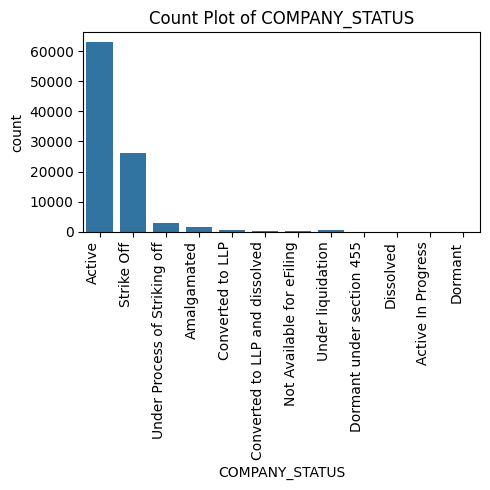

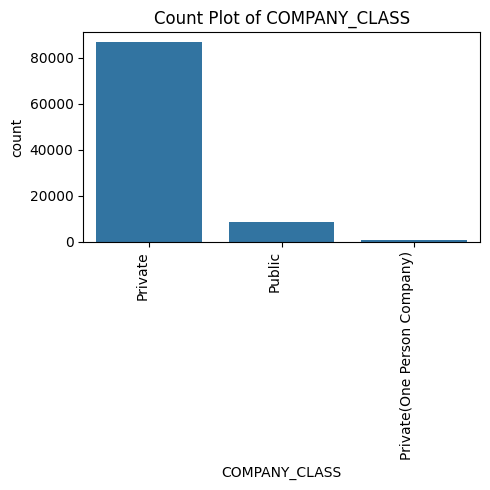

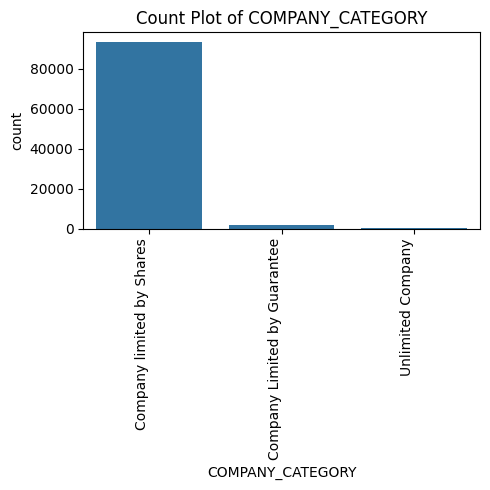

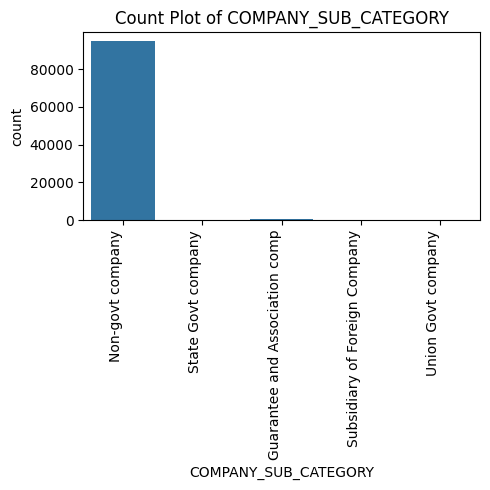

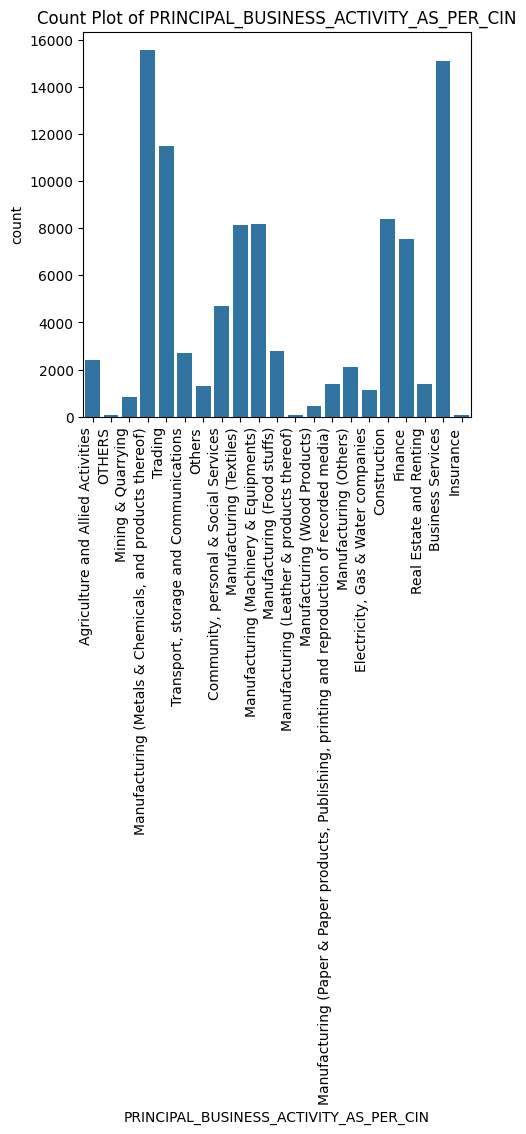

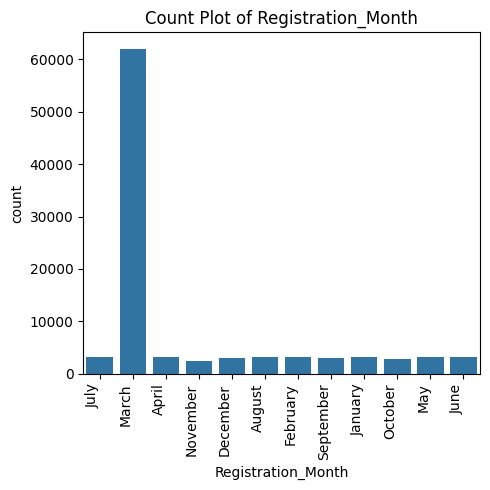

In [12]:

# Plot countplots for categorical columns
for col in categorical_cols:
    if col == 'Email_Domain' : continue
    plt.figure(figsize=(5, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()


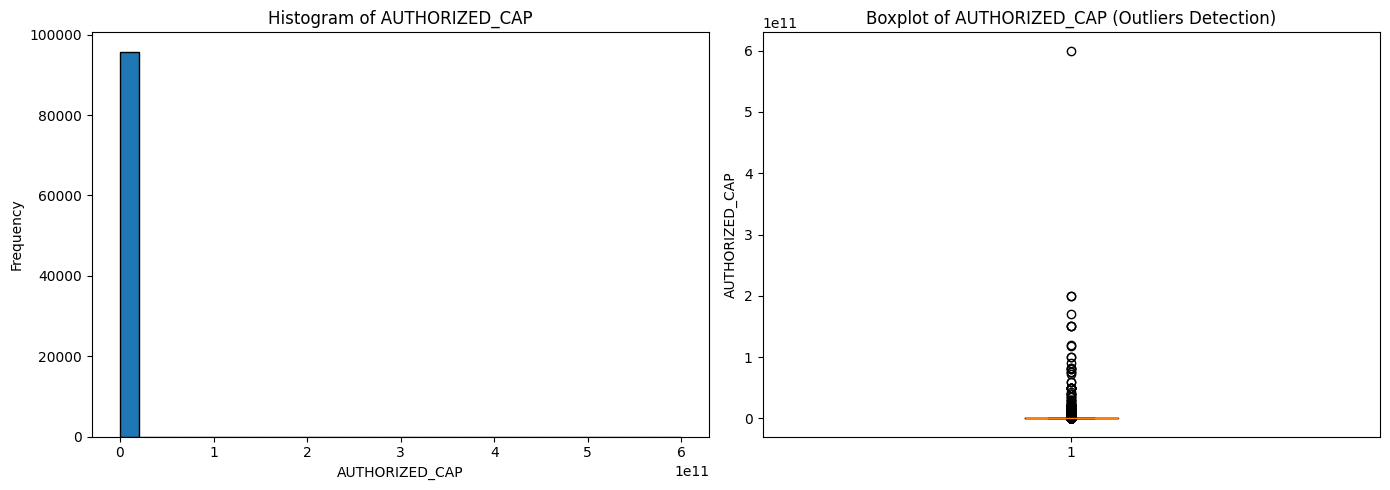

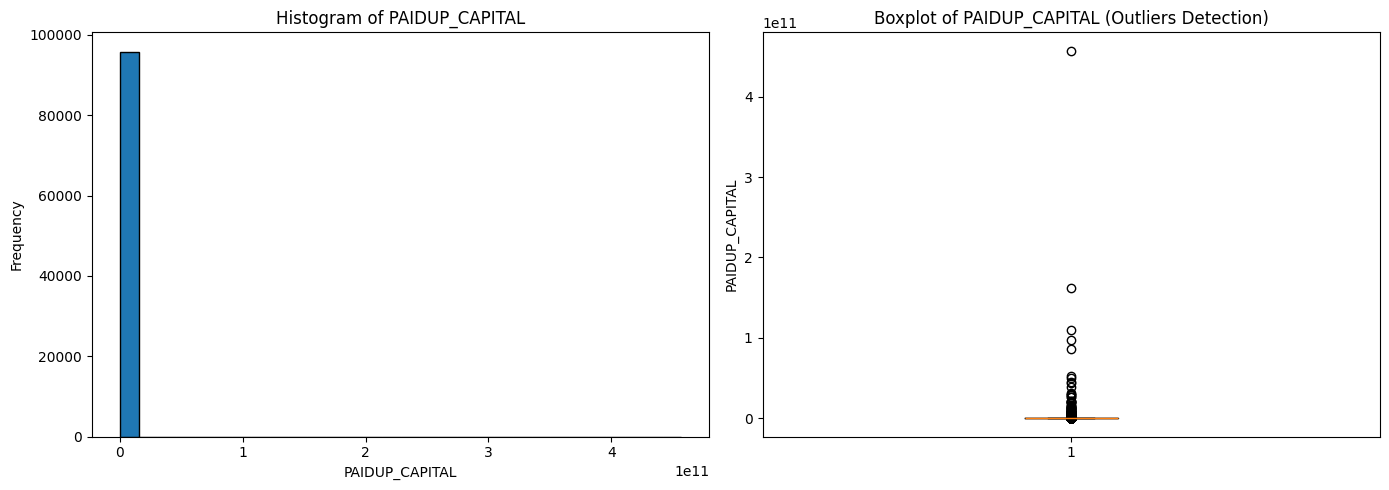

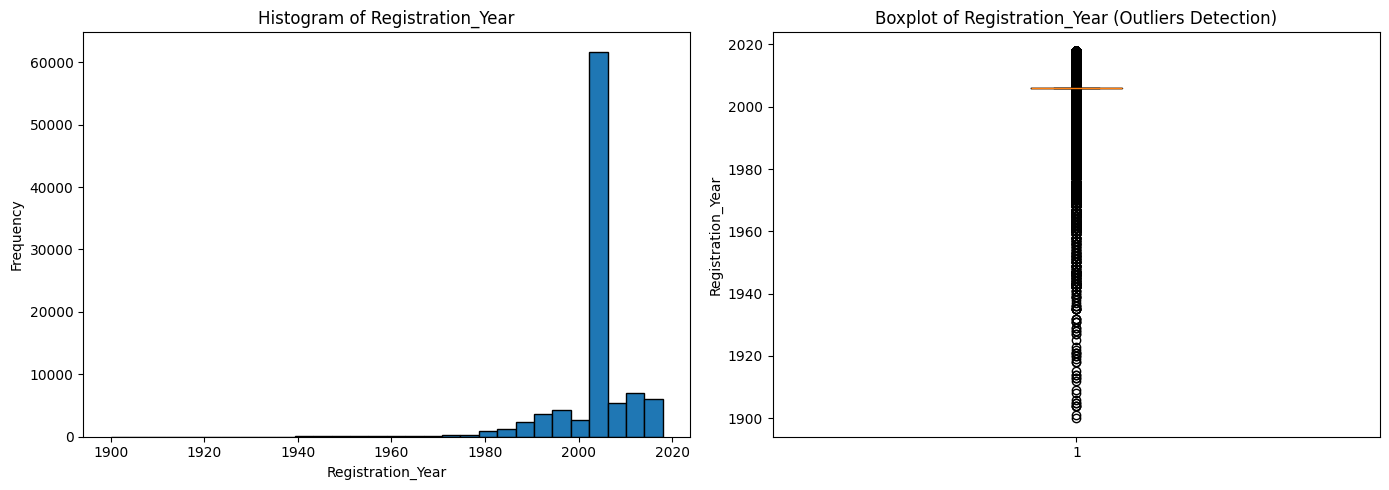

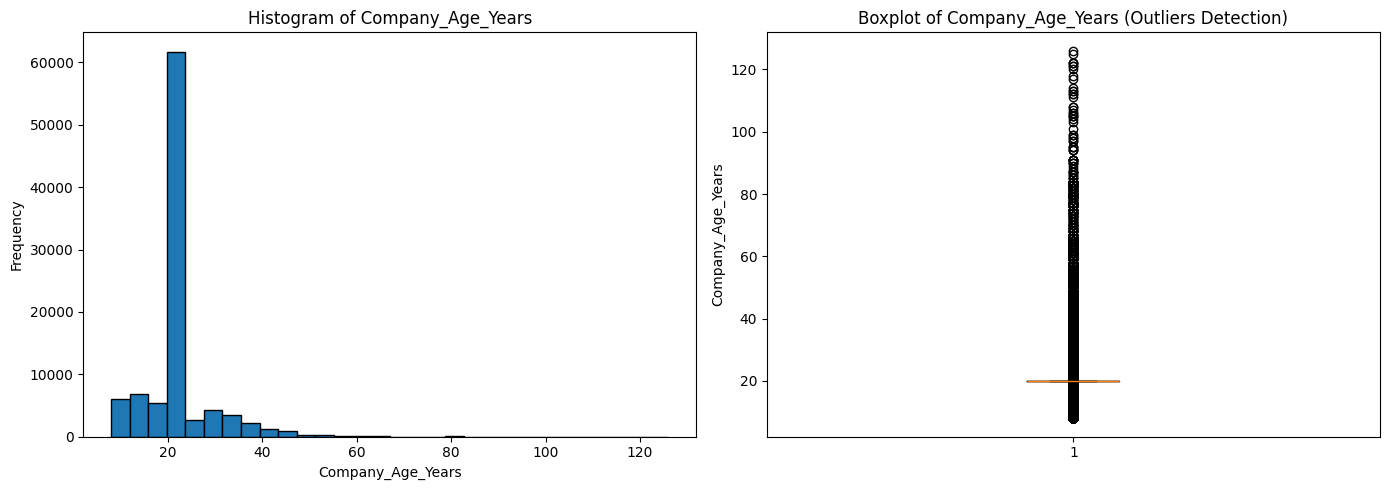

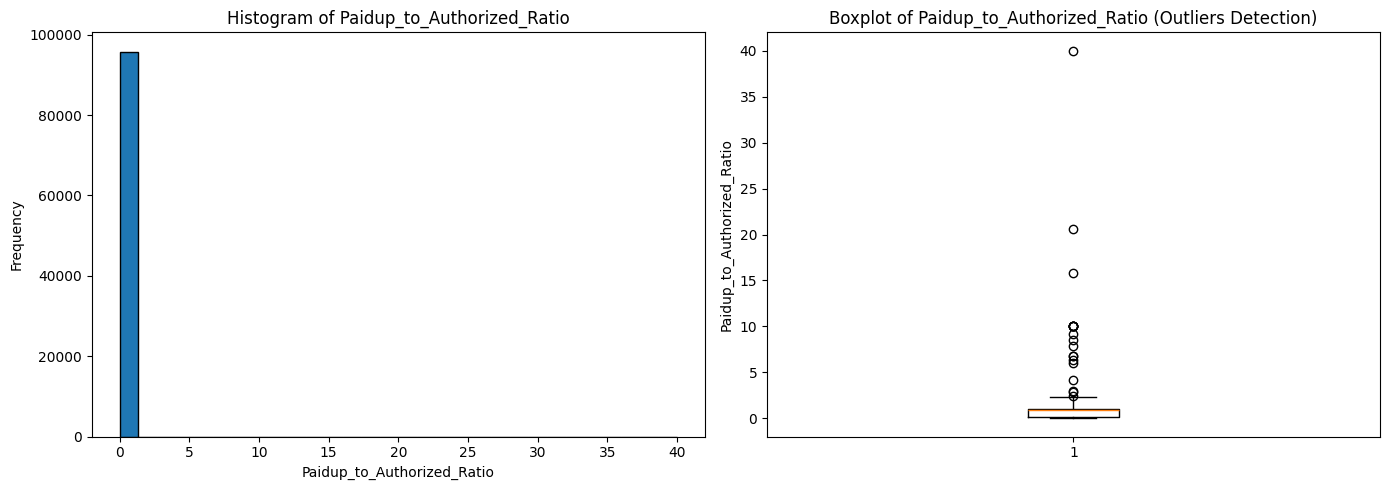

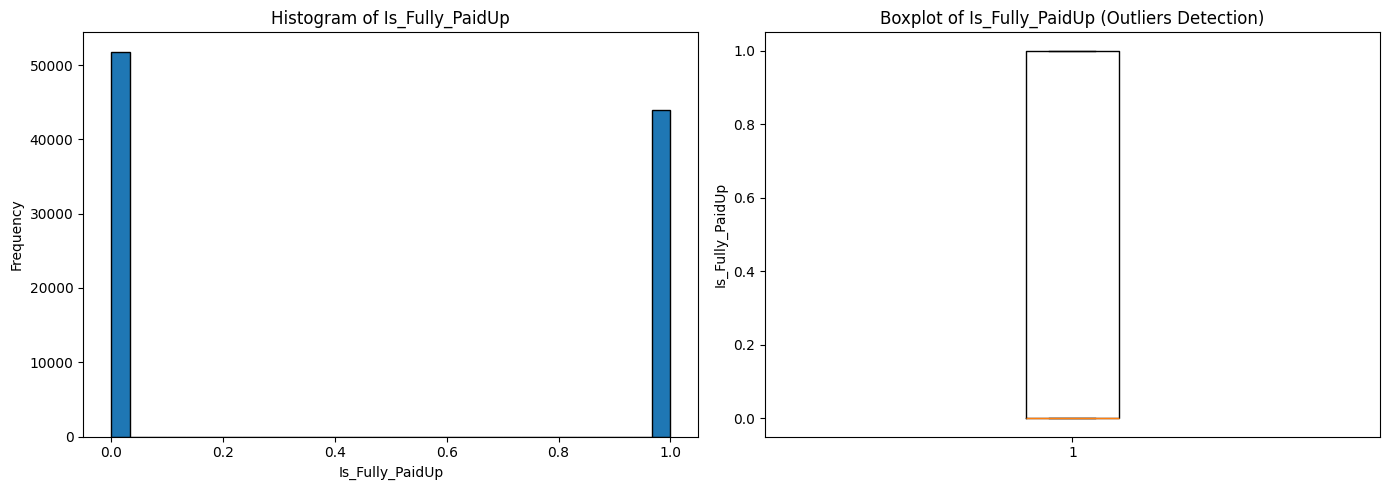

In [13]:

# Plot histograms and boxplots for continuous columns
for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df[col], bins=30, edgecolor='black')
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    axes[1].boxplot(df[col])
    axes[1].set_title(f'Boxplot of {col} (Outliers Detection)')
    axes[1].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()